In [20]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)
from PCA import PCA
from KMeans import KMeans
from sklearn.model_selection import train_test_split
from Metrics import silhouette_score_scratch as silhouette_score, calinski_harabasz_score_scratch as calinski_harabasz_score, davies_bouldin_score, calculate_gap_statistic
from ExternalValidations import adjusted_rand_index, normalized_mutual_information, purity_score, contingency_matrix

In [21]:
data = pd.read_csv('../data/data.csv')

y = data['diagnosis']
y = y.map({'M': 1, 'B': 0})



In [22]:
X = data.drop(columns=['diagnosis', 'id', 'Unnamed: 32'], errors='ignore')

x_train , x_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.299, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state=42)
print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (398, 30), Validation shape: (85, 30), Test shape: (86, 30)


In [23]:
# Standardize for pca kmeans and gmm
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)
x_train_standardized = (x_train - mean) / (std + 1e-8) #add small value to avoid division by zero

## 1. KMeans On Original Data

Calculating Metrics: Inertia, Silhouette, DBI, CHI
Converged at iteration number 9.
k=2: Inertia=8189, Sil=0.344, DBI=1.331, CHI=181
Converged at iteration number 8.
k=3: Inertia=7438, Sil=0.302, DBI=1.606, CHI=120
Converged at iteration number 19.
k=4: Inertia=6552, Sil=0.320, DBI=1.277, CHI=108
Converged at iteration number 11.
k=5: Inertia=6117, Sil=0.155, DBI=1.836, CHI=94
Converged at iteration number 14.
k=6: Inertia=5726, Sil=0.145, DBI=1.553, CHI=85
Converged at iteration number 21.
k=7: Inertia=5323, Sil=0.167, DBI=1.587, CHI=81
Converged at iteration number 20.
k=8: Inertia=5131, Sil=0.147, DBI=1.492, CHI=74
Converged at iteration number 22.
k=9: Inertia=4882, Sil=0.140, DBI=1.681, CHI=70
Converged at iteration number 12.
k=10: Inertia=4686, Sil=0.144, DBI=1.432, CHI=67

Gap Statistic:
Converged at iteration number 6.
Converged at iteration number 7.
Converged at iteration number 20.
Converged at iteration number 11.
  k=2: Gap=1.8336
Converged at iteration number 15.
Converg

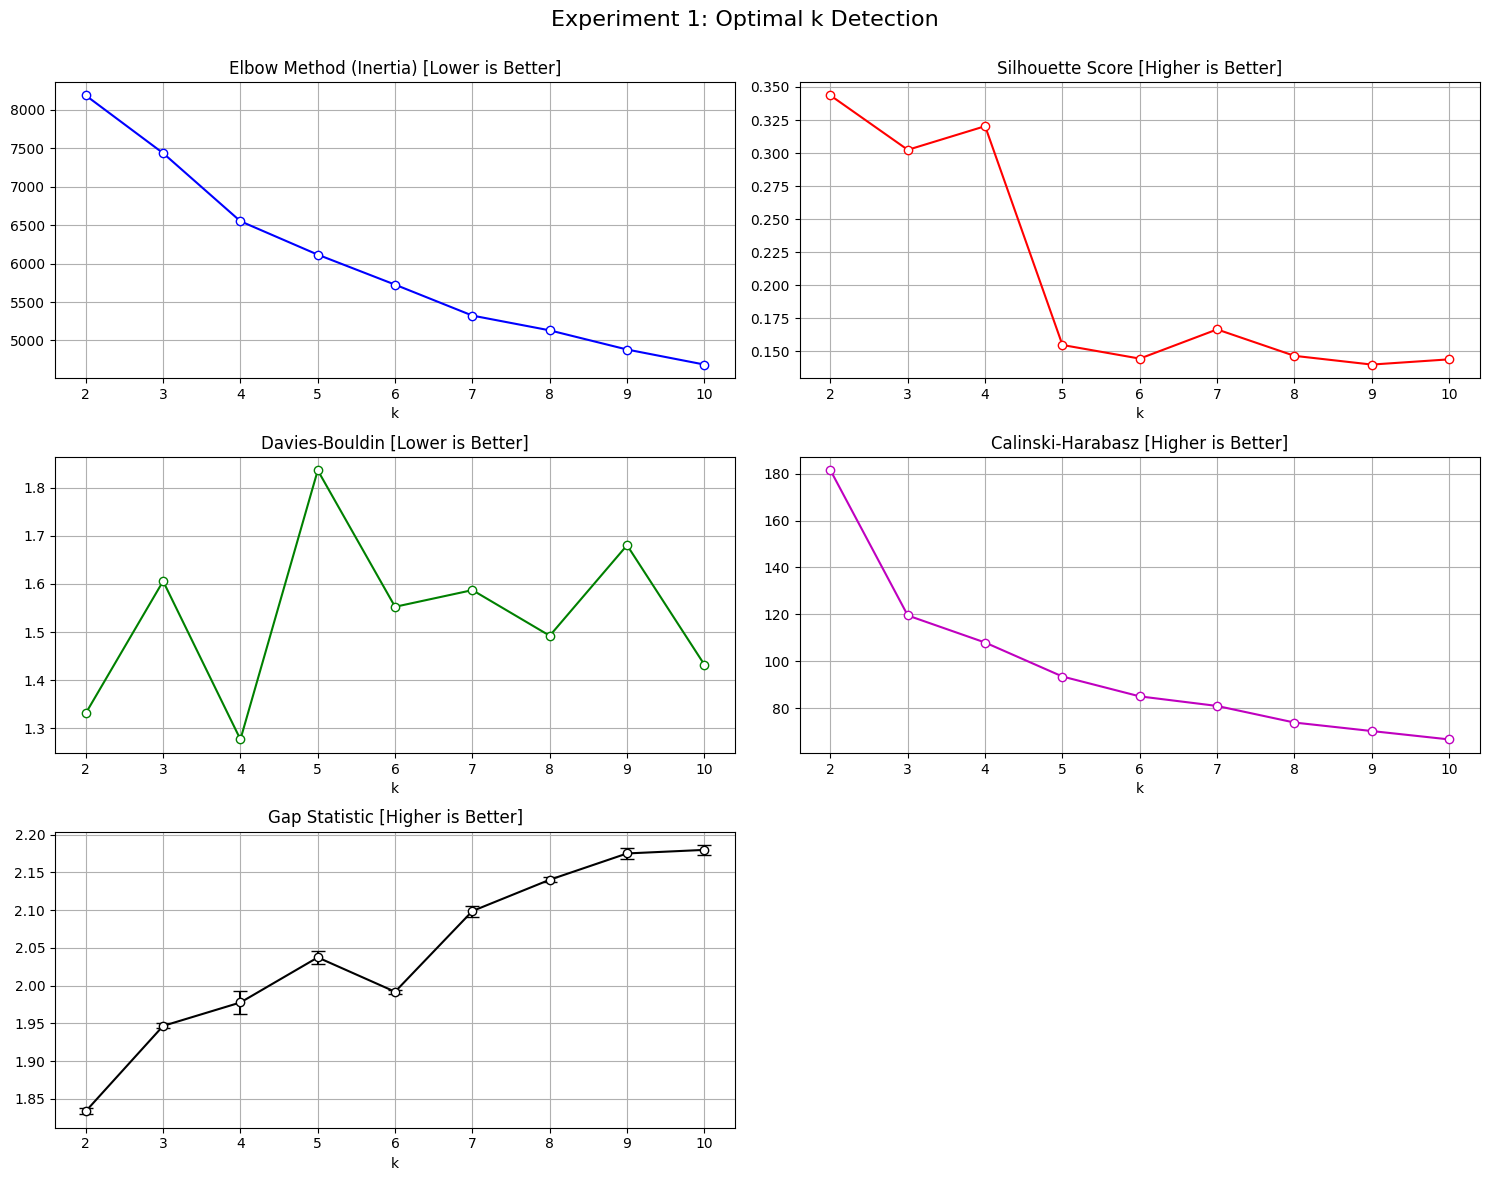

In [24]:
X_input = x_train_standardized.values 
k_values = range(2, 11)

inertias = []   # for Elbow Method
sil_scores = [] # for Silhouette Score
db_scores = []  # for Davies-Bouldin Index
ch_scores = []  # for Calinski-Harabasz Index

print("Calculating Metrics: Inertia, Silhouette, DBI, CHI")

for k in k_values:
    # Initialize and Fit
    km = KMeans(k=k, max_iterations=300, initialization_method='k-means++')
    km.fit(X_input)
    
    # Inertia (Elbow)
    inertias.append(km.inertia_history[-1])
    
    # Silhouette
    sil = silhouette_score(X_input, km.labels)
    sil_scores.append(sil)
    
    # Davies-Bouldin
    db = davies_bouldin_score(X_input, km.labels)
    db_scores.append(db)
    
    # Calinski-Harabasz
    ch = calinski_harabasz_score(X_input, km.labels)
    ch_scores.append(ch)
    
    print(f"k={k}: Inertia={inertias[-1]:.0f}, Sil={sil:.3f}, DBI={db:.3f}, CHI={ch:.0f}")

print("\nGap Statistic:")
# KMeans class is passed so the function can create new instances of it
gaps, std_diffs = calculate_gap_statistic(X_input, k_values, KMeans, n_refs=3) 

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Experiment 1: Optimal k Detection', fontsize=16)

# Inertia
axes[0, 0].plot(k_values, inertias, 'bo-', markerfacecolor='w')
axes[0, 0].set_title('Elbow Method (Inertia) [Lower is Better]')
axes[0, 0].set_xlabel('k')
axes[0, 0].grid(True)

# Silhouette
axes[0, 1].plot(k_values, sil_scores, 'ro-', markerfacecolor='w')
axes[0, 1].set_title('Silhouette Score [Higher is Better]')
axes[0, 1].set_xlabel('k')
axes[0, 1].grid(True)

# Davies-Bouldin
axes[1, 0].plot(k_values, db_scores, 'go-', markerfacecolor='w')
axes[1, 0].set_title('Davies-Bouldin [Lower is Better]')
axes[1, 0].set_xlabel('k')
axes[1, 0].grid(True)

# Calinski-Harabasz
axes[1, 1].plot(k_values, ch_scores, 'mo-', markerfacecolor='w')
axes[1, 1].set_title('Calinski-Harabasz [Higher is Better]')
axes[1, 1].set_xlabel('k')
axes[1, 1].grid(True)

# Gap Statistic
axes[2, 0].errorbar(k_values, gaps, yerr=std_diffs, fmt='ko-', capsize=5, markerfacecolor='w')
axes[2, 0].set_title('Gap Statistic [Higher is Better]')
axes[2, 0].set_xlabel('k')
axes[2, 0].grid(True)

# Hide empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

K = 2 is chosen, since 3 metrics agree on it (Silhouette, Davies-Bouldin, Calinski-Harabasz)

Running 100 trials for Comparison (k=2)
Converged at iteration number 6.
Converged at iteration number 7.
Converged at iteration number 7.
Converged at iteration number 7.
Converged at iteration number 6.
Converged at iteration number 6.
Converged at iteration number 8.
Converged at iteration number 9.
Converged at iteration number 9.
Converged at iteration number 11.
Converged at iteration number 5.
Converged at iteration number 6.
Converged at iteration number 7.
Converged at iteration number 4.
Converged at iteration number 4.
Converged at iteration number 6.
Converged at iteration number 7.
Converged at iteration number 5.
Converged at iteration number 5.
Converged at iteration number 5.
Converged at iteration number 6.
Converged at iteration number 5.
Converged at iteration number 6.
Converged at iteration number 6.
Converged at iteration number 10.
Converged at iteration number 7.
Converged at iteration number 7.
Converged at iteration number 6.
Converged at iteration number 7.
C

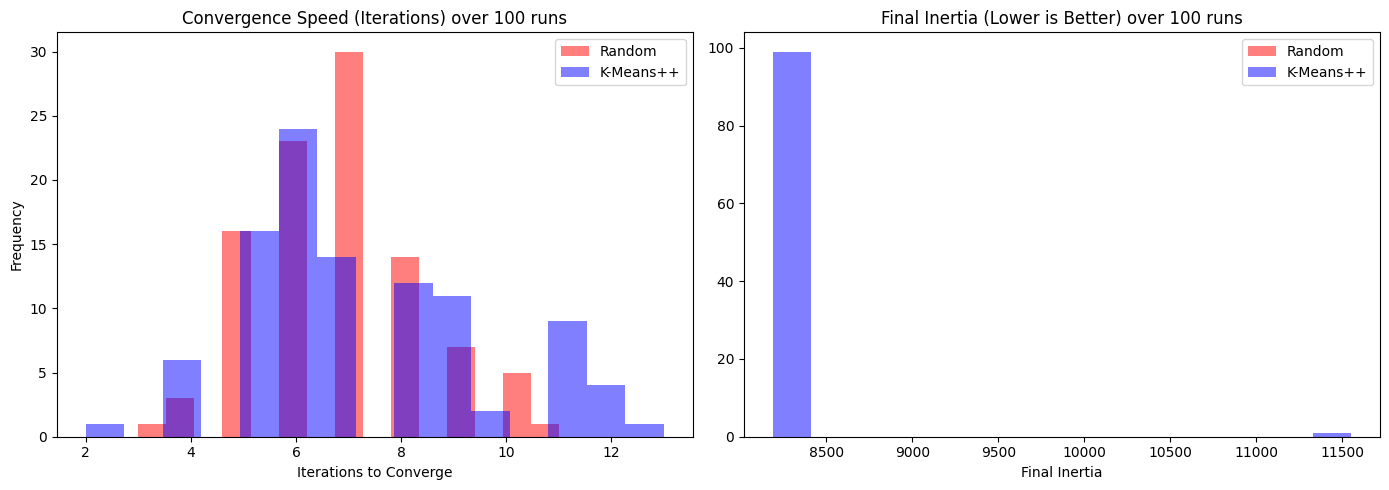

In [25]:
n_trials = 100
k_optimal = 2 # picked
X_input = x_train_standardized.values

random_iters = []
random_inertias = []
pp_iters = []
pp_inertias = []

print(f"Running {n_trials} trials for Comparison (k={k_optimal})")

for i in range(n_trials):
    # Random Initialization
    km_random = KMeans(k=k_optimal, max_iterations=300, initialization_method='random')
    km_random.fit(X_input)
    random_iters.append(len(km_random.inertia_history))   # Number of iterations
    random_inertias.append(km_random.inertia_history[-1]) # Final Inertia

    # K-Means++ Initialization
    km_pp = KMeans(k=k_optimal, max_iterations=300, initialization_method='k-means++')
    km_pp.fit(X_input)
    pp_iters.append(len(km_pp.inertia_history))
    pp_inertias.append(km_pp.inertia_history[-1])

# Statistics
print("\nResults:")
print(f"Random Init: Average Iterations = {np.mean(random_iters):.2f}, Average Inertia = {np.mean(random_inertias):.2f}")
print(f"K-Means++  : Average Iterations = {np.mean(pp_iters):.2f}, Average Inertia = {np.mean(pp_inertias):.2f}")

# Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Convergence Speed -> Iterations
axes[0].hist(random_iters, alpha=0.5, label='Random', bins=15, color='red')
axes[0].hist(pp_iters, alpha=0.5, label='K-Means++', bins=15, color='blue')
axes[0].set_title(f'Convergence Speed (Iterations) over {n_trials} runs')
axes[0].set_xlabel('Iterations to Converge')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Inertia
axes[1].hist(random_inertias, alpha=0.5, label='Random', bins=15, color='red')
axes[1].hist(pp_inertias, alpha=0.5, label='K-Means++', bins=15, color='blue')
axes[1].set_title(f'Final Inertia (Lower is Better) over {n_trials} runs')
axes[1].set_xlabel('Final Inertia')
axes[1].legend()

plt.tight_layout()
plt.show()

Since it's k=2, kmeans++ initialization didn't make much difference than random initialization. Both of them got the same minimum inertia, but there's one outlier in kmeans++ that hit a local minima.

#### External Validation

In [ ]:
def evaluate_external_metrics(y_true, y_pred):
    ari = adjusted_rand_index(y_true, y_pred)
    nmi = normalized_mutual_information(y_true, y_pred)
    purity = purity_score(y_true, y_pred)
    cm = contingency_matrix(y_true, y_pred)
    
    print(f"External Metrics:")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
    print(f"Purity Score: {purity:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

In [ ]:
# K-Means++
print("K-Means++ with k=2...")
kmeans_pp = KMeans(k=2, initialization_method='k-means++', max_iterations=1000)
kmeans_pp.fit(x_train_standardized.values) # Fit on Train

# Predict
x_test_standardized = (x_test - mean) / (std + 1e-8)
y_pred_pp = kmeans_pp.predict(x_test_standardized.values)

# Convergence Speed
print(f"K-Means++ Convergence: {len(kmeans_pp.inertia_history)} iterations")

# Evaluate External Metrics
evaluate_external_metrics(y_test.values.flatten(), y_pred_pp)


# Random Initialization
print("Random Init with k=2...")
kmeans_random = KMeans(k=2, initialization_method='random', max_iterations=1000)
kmeans_random.fit(x_train_standardized.values)

# Predict on Test
y_pred_random = kmeans_random.predict(x_test_standardized.values)

# Convergence Speed
print(f"Random Init Convergence: {len(kmeans_random.inertia_history)} iterations")

# Evaluate External Metrics
evaluate_external_metrics(y_test.values.flatten(), y_pred_random)

Running K-Means++ with k=2...
Converged at iteration number 7.
K-Means++ Convergence: 7 iterations
K-Means++ External Metrics:
Adjusted Rand Index (ARI): 0.6879
Normalized Mutual Info (NMI): 0.5542
Purity Score: 0.9186
Confusion Matrix:
[[ 2 58]
 [21  5]]

Running K-Means (Random Init) with k=2...
Converged at iteration number 6.
Random Init Convergence: 6 iterations
Random Init External Metrics:
Adjusted Rand Index (ARI): 0.6879
Normalized Mutual Info (NMI): 0.5542
Purity Score: 0.9186
Confusion Matrix:
[[ 2 58]
 [21  5]]



## 3. KMeans with PCA

K-Means (k=2) after PCA
Converged at iteration number 6.
Components=2: MSE=0.3699 | Sil=0.507, DBI=0.848, CHI=390
Converged at iteration number 10.
Components=5: MSE=0.1551 | Sil=0.392, DBI=1.154, CHI=234
Converged at iteration number 6.
Components=10: MSE=0.0486 | Sil=0.356, DBI=1.279, CHI=195
Converged at iteration number 9.
Components=15: MSE=0.0130 | Sil=0.345, DBI=1.319, CHI=185
Converged at iteration number 11.
Components=20: MSE=0.0042 | Sil=0.343, DBI=1.328, CHI=183


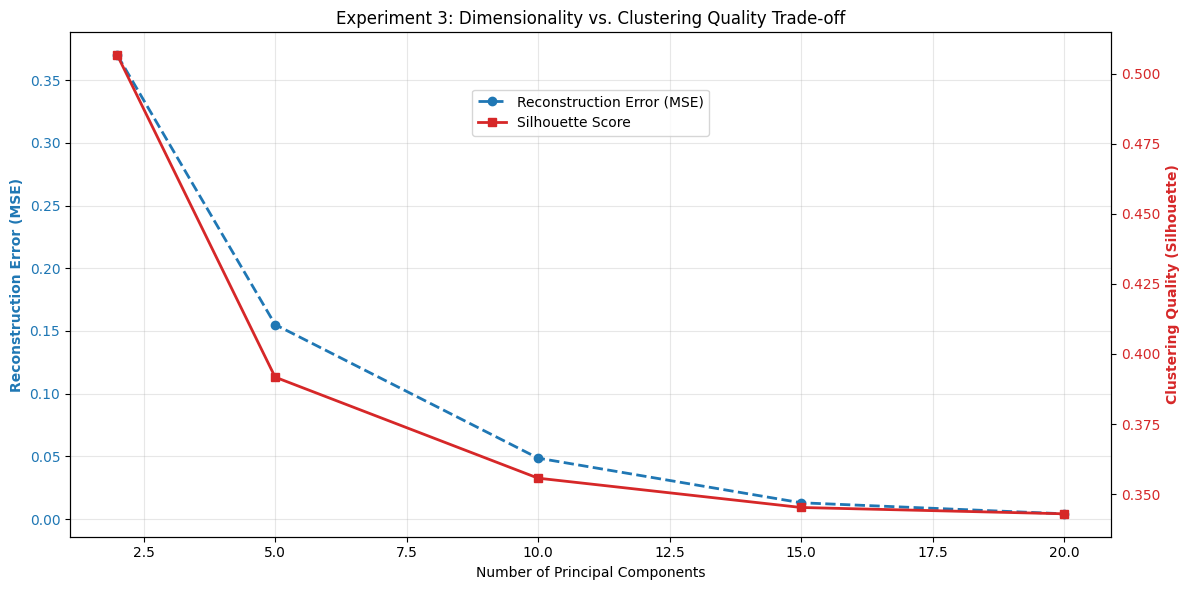

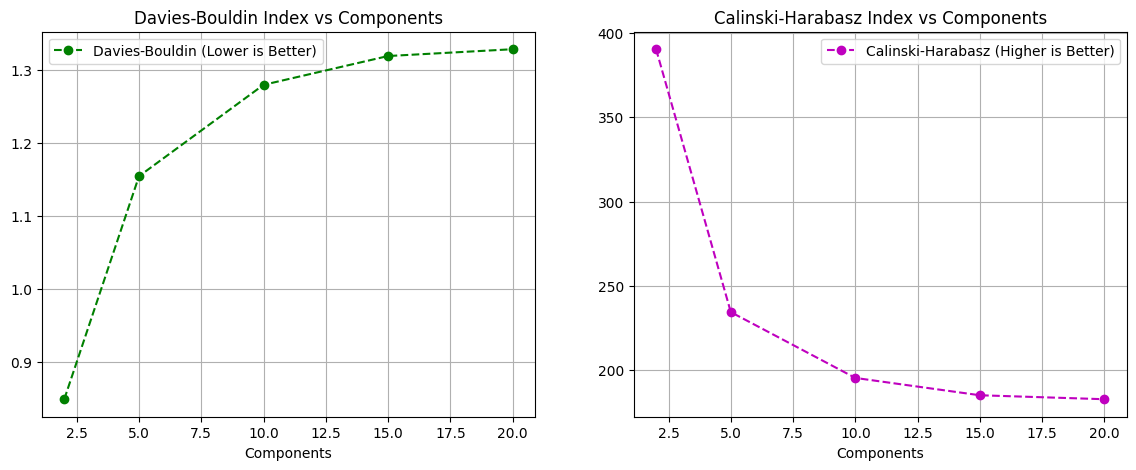

In [28]:
components_list = [2, 5, 10, 15, 20]
X_std = x_train_standardized.values
k = 2

mse_list = []  # Reconstruction Error
sil_list = []  # Silhouette
dbi_list = []  # Davies-Bouldin
chi_list = []  # Calinski-Harabasz
wcss_list = [] # Within-Cluster Sum of Squares

print(f"K-Means (k={k}) after PCA")

for n in components_list:
    # Apply PCA
    pca = PCA(number_of_components=n)
    pca.fit(X_std)
    X_pca = pca.transform(X_std)
    
    reconsturtion_error = pca.get_reconstruction_error(X_std)
    mse_list.append(reconsturtion_error)
    
    # Run K-Means on Reduced Data
    km = KMeans(k=k, max_iterations=300, initialization_method='k-means++')
    km.fit(X_pca)
    
    # Calculate Metrics
    sil = silhouette_score(X_pca, km.labels)
    dbi = davies_bouldin_score(X_pca, km.labels)
    chi = calinski_harabasz_score(X_pca, km.labels)
    
    sil_list.append(sil)
    dbi_list.append(dbi)
    chi_list.append(chi)
    wcss_list.append(km.inertia_history[-1])
    
    print(f"Components={n}: MSE={reconsturtion_error:.4f} | Sil={sil:.3f}, DBI={dbi:.3f}, CHI={chi:.0f}")

# Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Number of Principal Components')
ax1.set_ylabel('Reconstruction Error (MSE)', color='tab:blue', fontweight='bold')
ax1.plot(components_list, mse_list, 'o--', color='tab:blue', label='Reconstruction Error (MSE)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Create a second y-axis for the Clustering Metrics
ax2 = ax1.twinx()
ax2.set_ylabel('Clustering Quality (Silhouette)', color='tab:red', fontweight='bold')
ax2.plot(components_list, sil_list, 's-', color='tab:red', label='Silhouette Score', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Experiment 3: Dimensionality vs. Clustering Quality Trade-off')
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), bbox_transform=ax1.transAxes)

plt.tight_layout()
plt.show()

# Plot other metrics separately
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(components_list, dbi_list, 'go--', label='Davies-Bouldin (Lower is Better)')
ax1.set_title('Davies-Bouldin Index vs Components')
ax1.set_xlabel('Components')
ax1.grid(True)
ax1.legend()

ax2.plot(components_list, chi_list, 'mo--', label='Calinski-Harabasz (Higher is Better)')
ax2.set_title('Calinski-Harabasz Index vs Components')
ax2.set_xlabel('Components')
ax2.grid(True)
ax2.legend()
plt.show()

Optimal number of components is 2, all metrics agree on it. In the first graph, when we decrease the number of components, the reconstruction error (MSE) increases and while the clustering quality metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) improve, suggesting that reducing dimensionality to 2 components helps in better clustering performance while keeping reconstruction error low. This agrees with previous lab: Decision Trees, where a few features were sufficient for good classification, while the rest of the features were never used.